# Free-atom surface reconstruction at glancing incidence

This notebook applies the minimal free-atom reconstruction to the pristine silicon geometry from `sideview_glancing_silicon_viewer_1d.ipynb`. It first displays the known forward model, then asks whether diffraction data can determine an unknown number of silicon atoms in one surface row from sixteen uniform non-lattice candidates.

In [1]:
%matplotlib widget

from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "wide_angle_propagation").is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from ase.build import bulk
import ipywidgets as widgets
import jax
import jax.numpy as jnp
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from matplotlib.colors import PowerNorm
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist

from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel_1d,
    energy2wavelength,
)
from wide_angle_propagation.ptychography_1d import (
    reconstruct_potential_1d,
    simulate_glancing_scan_1d,
    simulate_glancing_sideview_cache_1d,
)
from wide_angle_propagation.ptychography_atoms_1d import (
    FreeAtomModel1D,
    make_si_atom_template_1d,
    reconstruct_free_atoms_1d,
    render_free_atoms_1d,
    uniform_atom_candidates_1d,
)
from wide_angle_propagation.sideview_geometry import make_tilted_gaussian_beam_1d

jax.config.update("jax_enable_x64", True)

## 1. Construct the pristine atomic specimen

The energy, angle, field of view, silicon depth and numerical sampling match the pristine viewer. The truth is rendered explicitly from projected Lobato Si atoms so the reconstruction and truth use the same finite atomic kernel. The independent tiled-abTEM viewer remains a useful forward-model mismatch test for later work.

In [2]:
energy_eV = 30_000.0
glancing_angle_deg = 2.0
beam_tilt_rad = -np.deg2rad(glancing_angle_deg)
beam_waist_A = 3.0
propagation_length_A = 250.0
slab_depth_A = 15.0
vacuum_above_A = 40.0
vacuum_below_A = 20.0
si_lattice_A = 5.431
ds = 0.3394375
du = 0.1467837837837838

n_s = int(np.ceil(propagation_length_A / ds))
n_u = int(np.ceil((slab_depth_A + vacuum_above_A + vacuum_below_A) / du))
n_u += n_u % 2
s_A = np.arange(n_s) * ds
u_A = (np.arange(n_u) - n_u // 2) * du

si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
top_atom_x_A = float(np.max(si_unit.positions[:, 0]))
projected_basis_A = np.asarray(si_unit.positions[:, [2, 0]])
all_sites = []
for cell_s in range(-1, int(np.ceil(s_A[-1] / si_lattice_A)) + 2):
    for cell_u in range(-int(np.ceil(slab_depth_A / si_lattice_A)) - 2, 1):
        for basis_s_A, basis_x_A in projected_basis_A:
            site = (
                basis_s_A + cell_s * si_lattice_A,
                basis_x_A - top_atom_x_A + cell_u * si_lattice_A,
            )
            if 0.0 <= site[0] <= s_A[-1] and -slab_depth_A <= site[1] <= 0.0:
                all_sites.append(site)
all_sites_A = np.unique(np.round(np.asarray(all_sites), decimals=10), axis=0)
si_template = make_si_atom_template_1d(
    ds, du, cutoff_A=4.0, projection_width_A=si_lattice_A
)
print({
    "grid shape": (n_s, n_u),
    "sampling (ds, du) Å": (ds, du),
    "projected Si sites in slab": len(all_sites_A),
    "atomic template shape": si_template.shape,
})

{'grid shape': (737, 512), 'sampling (ds, du) Å': (0.3394375, 0.1467837837837838), 'projected Si sites in slab': 1110, 'atomic template shape': (25, 57)}


## 2. Declare the surface-row reconstruction region

The silicon outside the small surface box is known and held fixed. Inside the box the reconstruction receives no lattice sites or atom count: sixteen candidates start uniformly across the box and may move by up to 0.75 Å. The private truth contains eight surface atoms and is used only to simulate data and score the result.

E0712 20:29:16.510963  197639 hlo_lexer.cc:443] Failed to parse int literal: 108767730567710902644207158


{'private truth atoms': 8, 'uniform candidates': 16, 'fitted specimen values': 48, 'fixed exterior atoms': 1102}


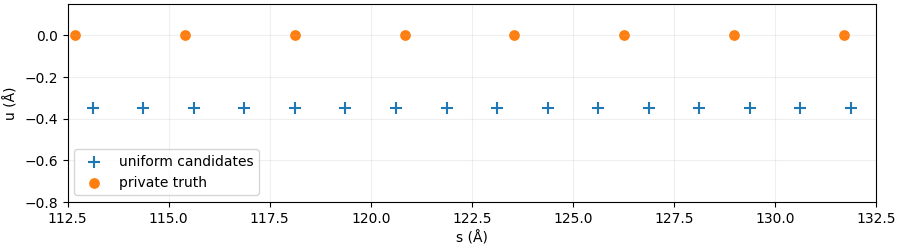

In [3]:
scan_landing_bounds_A = np.asarray([105.0, 140.0])
axial_edge_guard_A = 2.5 * beam_waist_A
candidate_bounds_A = np.asarray([
    [scan_landing_bounds_A[0] + axial_edge_guard_A,
     scan_landing_bounds_A[1] - axial_edge_guard_A],
    [-0.7, 0.0],
])
inside = (
    (all_sites_A[:, 0] >= candidate_bounds_A[0, 0])
    & (all_sites_A[:, 0] <= candidate_bounds_A[0, 1])
    & (all_sites_A[:, 1] >= candidate_bounds_A[1, 0])
    & (all_sites_A[:, 1] <= candidate_bounds_A[1, 1])
)
truth_sites_A = all_sites_A[inside]
fixed_sites_A = all_sites_A[~inside]
full_material_bounds_A = np.asarray([[0.0, s_A[-1]], [-slab_depth_A, 0.0]])

fixed_model = FreeAtomModel1D(
    jnp.asarray(s_A), jnp.asarray(u_A), si_template, full_material_bounds_A,
    jnp.asarray(fixed_sites_A), maximum_displacement_A=0.1,
)
fixed_potential = render_free_atoms_1d(
    fixed_model, jnp.asarray(fixed_sites_A), jnp.ones(len(fixed_sites_A))
)
truth_model = FreeAtomModel1D(
    jnp.asarray(s_A), jnp.asarray(u_A), si_template, candidate_bounds_A,
    jnp.asarray(truth_sites_A), fixed_potential=fixed_potential,
    maximum_displacement_A=0.1,
)
truth_potential = render_free_atoms_1d(
    truth_model, jnp.asarray(truth_sites_A), jnp.ones(len(truth_sites_A))
)
candidate_positions_A = uniform_atom_candidates_1d(candidate_bounds_A, (16, 1))
model = FreeAtomModel1D(
    jnp.asarray(s_A), jnp.asarray(u_A), si_template, candidate_bounds_A,
    candidate_positions_A, fixed_potential=fixed_potential,
    maximum_displacement_A=0.75,
    metadata={"species": "Si", "region": "calibrated surface row"},
)
print({
    "private truth atoms": len(truth_sites_A),
    "uniform candidates": len(candidate_positions_A),
    "fitted specimen values": 3 * len(candidate_positions_A),
    "fixed exterior atoms": len(fixed_sites_A),
})

fig, ax = plt.subplots(figsize=(9, 2.5), constrained_layout=True)
ax.scatter(candidate_positions_A[:, 0], candidate_positions_A[:, 1], marker="+", s=80, label="uniform candidates")
ax.scatter(truth_sites_A[:, 0], truth_sites_A[:, 1], s=45, label="private truth")
ax.set(xlim=candidate_bounds_A[0], ylim=(-0.8, 0.15), xlabel="s (Å)", ylabel="u (Å)")
ax.legend(); ax.grid(alpha=0.2)

## 3. Simulate the fixed-probe glancing scan

Forty-one known probes land from 105 to 140 Å. Every fifth diffraction pattern is held out for checkpoint selection. The same propagated fields feed both the reconstruction and the interactive viewer.

In [4]:
scan_coordinates_A = np.linspace(*scan_landing_bounds_A, 41)
beam_centres_at_entrance_A = -scan_coordinates_A * np.tan(beam_tilt_rad)
input_probes = jnp.stack([
    make_tilted_gaussian_beam_1d(
        jnp.asarray(u_A), energy_eV, waist=beam_waist_A,
        center=float(center_A), tilt=beam_tilt_rad,
    )
    for center_A in beam_centres_at_entrance_A
]).astype(jnp.complex128)
kernel = angular_spectrum_propagation_kernel_1d(n_u, du, ds, energy_eV)
window_starts = jnp.zeros(len(scan_coordinates_A), dtype=jnp.int32)
measured_intensities = simulate_glancing_scan_1d(
    truth_potential, input_probes, window_starts, n_s, kernel, ds, energy_eV
)
validation_indices = np.arange(0, len(scan_coordinates_A), 5)
truth_sideviews = simulate_glancing_sideview_cache_1d(
    truth_potential, input_probes, window_starts, n_s, kernel, ds, energy_eV,
    jnp.arange(len(scan_coordinates_A)),
    transverse_coordinates=jnp.asarray(u_A),
    scan_coordinates=jnp.asarray(scan_coordinates_A),
    axial_stride=4, transverse_stride=2,
)
wavelength_A = float(energy2wavelength(energy_eV))
detector_frequencies = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
detector_angles_mrad = 1e3 * np.arcsin(np.clip(wavelength_A * detector_frequencies, -1.0, 1.0))
print(f"Simulated {len(scan_coordinates_A)} scans; {len(validation_indices)} are held out.")

Simulated 41 scans; 9 are held out.


## 4. Inspect the forward model before inversion

In [5]:
def make_scan_viewer(caches, potentials):
    names = tuple(caches)
    side_max = max(float(np.max(np.asarray(cache.sideview_intensities))) for cache in caches.values())
    exit_max = max(float(np.max(np.abs(np.asarray(cache.exit_waves)) ** 2)) for cache in caches.values())
    detector_max = max(float(np.max(np.asarray(cache.detector_intensities))) for cache in caches.values())
    potential_max = max(float(np.max(np.asarray(value))) for value in potentials.values())
    with plt.ioff():
        figure = plt.figure(figsize=(14, 6.5), constrained_layout=True)

    def draw(scan_index, source):
        scan_index = int(scan_index)
        cache = caches[source]
        potential = np.asarray(potentials[source])
        figure.clear()
        grid = figure.add_gridspec(2, 2, width_ratios=(2.3, 1.0))
        side_ax = figure.add_subplot(grid[:, 0])
        exit_ax = figure.add_subplot(grid[0, 1])
        detector_ax = figure.add_subplot(grid[1, 1])
        side_s = np.asarray(cache.local_s_coordinates)
        side_u = np.asarray(cache.sideview_u_coordinates)
        side_ax.imshow(
            potential.T, origin="lower", aspect="auto",
            extent=[s_A[0], s_A[-1], u_A[0], u_A[-1]], cmap="plasma",
            norm=PowerNorm(gamma=0.45, vmin=max(potential_max * 1e-4, 1e-12), vmax=potential_max), alpha=0.55,
        )
        image = side_ax.imshow(
            np.asarray(cache.sideview_intensities[scan_index]).T, origin="lower", aspect="auto",
            extent=[side_s[0], side_s[-1], side_u[0], side_u[-1]], cmap="viridis",
            norm=PowerNorm(gamma=0.5, vmin=0.0, vmax=side_max), alpha=0.9,
        )
        landing = float(scan_coordinates_A[scan_index])
        side_ax.plot(side_s, np.tan(beam_tilt_rad) * (side_s - landing), "w--", linewidth=1.2)
        side_ax.scatter([landing], [0.0], color="cyan", edgecolor="black", s=45, zorder=5)
        side_ax.axhline(0.0, color="cyan", linewidth=0.8)
        side_ax.axhline(-slab_depth_A, color="cyan", linewidth=0.8)
        side_ax.set(xlim=(s_A[0], s_A[-1]), ylim=(-20.0, 18.0), xlabel="s (Å)", ylabel="u (Å)", title=f"{source}; landing at {landing:.1f} Å")
        figure.colorbar(image, ax=side_ax, label="beam intensity")
        exit_ax.plot(u_A, np.abs(np.asarray(cache.exit_waves[scan_index])) ** 2)
        exit_ax.set(xlim=(-5.0, 20.0), ylim=(0.0, exit_max * 1.03), xlabel="u (Å)", ylabel="intensity", title="Exit wave")
        detector_ax.semilogy(detector_angles_mrad, np.asarray(cache.detector_intensities[scan_index]) + 1e-30)
        detector_ax.set(xlabel="detector angle (mrad)", ylabel="intensity", title="Far field", ylim=(max(detector_max * 1e-10, 1e-30), detector_max * 1.1))
        figure.canvas.draw_idle()

    slider = widgets.SelectionSlider(
        options=[(f"{index:02d} — {landing:6.1f} Å", index) for index, landing in enumerate(scan_coordinates_A)],
        value=len(scan_coordinates_A) // 2, description="landing position",
        continuous_update=False, style={"description_width": "initial"},
        layout=widgets.Layout(width="720px"),
    )
    source = widgets.ToggleButtons(options=names, description="potential")
    slider.observe(lambda change: draw(change["new"], source.value), names="value")
    source.observe(lambda change: draw(slider.value, change["new"]), names="value")
    draw(slider.value, source.value)
    viewer = widgets.VBox([slider, source, figure.canvas])
    display(viewer)
    return viewer

truth_viewer = make_scan_viewer({"ground truth": truth_sideviews}, {"ground truth": truth_potential})

## 5. Reconstruct the surface row

The fixed probe and known exterior are held constant. For the first 100 updates only occupancies change; the remaining updates move positions as well. Repulsion is stronger than in the isolated nine-atom test because the projected Si row has a well-defined minimum spacing.

In [6]:
result = reconstruct_free_atoms_1d(
    model, input_probes, window_starts, n_s, kernel, ds, energy_eV, measured_intensities,
    validation_indices=validation_indices,
    updates=1000, occupancy_only_updates=100, minibatch_size=8,
    validation_interval=20, repulsion_weight=5e-2,
    progress=True, progress_description="glancing surface row",
)

glancing surface row:   0%|          | 0/1000 [00:00<?, ?update/s]

## 6. Open the private truth and apply the structural gate

In [7]:
active = np.asarray(result.occupancies) >= 0.5
recovered_sites_A = np.asarray(result.positions)[active]
distances = np.linalg.norm(recovered_sites_A[:, None] - truth_sites_A[None], axis=-1)
rows, columns = linear_sum_assignment(distances)
matched_errors_A = distances[rows, columns]
true_positives = int(np.sum(matched_errors_A <= 0.5))
position_rmse_A = (
    float(np.sqrt(np.mean(matched_errors_A**2)))
    if len(recovered_sites_A) == len(truth_sites_A) else np.inf
)
minimum_pair_A = float(np.min(pdist(recovered_sites_A))) if len(recovered_sites_A) > 1 else np.inf
validation_nrmse = float(np.nanmin(result.validation_loss_history))

cutoff_A = 4.0
pixel_halo = (
    (s_A[:, None] >= candidate_bounds_A[0, 0] - cutoff_A)
    & (s_A[:, None] <= candidate_bounds_A[0, 1] + cutoff_A)
    & (u_A[None, :] >= candidate_bounds_A[1, 0] - cutoff_A)
    & (u_A[None, :] <= candidate_bounds_A[1, 1] + cutoff_A)
)
metrics = {
    "truth atoms": len(truth_sites_A),
    "recovered atoms": len(recovered_sites_A),
    "false positives": len(recovered_sites_A) - true_positives,
    "missing atoms": len(truth_sites_A) - true_positives,
    "position RMSE Å": position_rmse_A,
    "largest position error Å": float(np.max(matched_errors_A)),
    "minimum recovered spacing Å": minimum_pair_A,
    "validation amplitude NRMSE": validation_nrmse,
    "atom parameters": int(result.metadata["n_specimen_parameters"]),
    "pixel values in atomic halo": int(pixel_halo.sum()),
    "parameter reduction": float(pixel_halo.sum() / result.metadata["n_specimen_parameters"]),
}
display(metrics)
assert metrics["recovered atoms"] == metrics["truth atoms"] == 8
assert metrics["false positives"] == 0 and metrics["missing atoms"] == 0
assert metrics["position RMSE Å"] <= 0.25
assert metrics["minimum recovered spacing Å"] >= 1.8
assert metrics["validation amplitude NRMSE"] < 1e-3
print("PASS: the pristine glancing surface-row gate is satisfied.")

{'truth atoms': 8,
 'recovered atoms': 8,
 'false positives': 0,
 'missing atoms': 0,
 'position RMSE Å': 5.058038728340211e-05,
 'largest position error Å': 8.715650761814686e-05,
 'minimum recovered spacing Å': 2.7153956312864125,
 'validation amplitude NRMSE': 3.344913061161613e-07,
 'atom parameters': 48,
 'pixel values in atomic halo': 4980,
 'parameter reduction': 103.75}

PASS: the pristine glancing surface-row gate is satisfied.


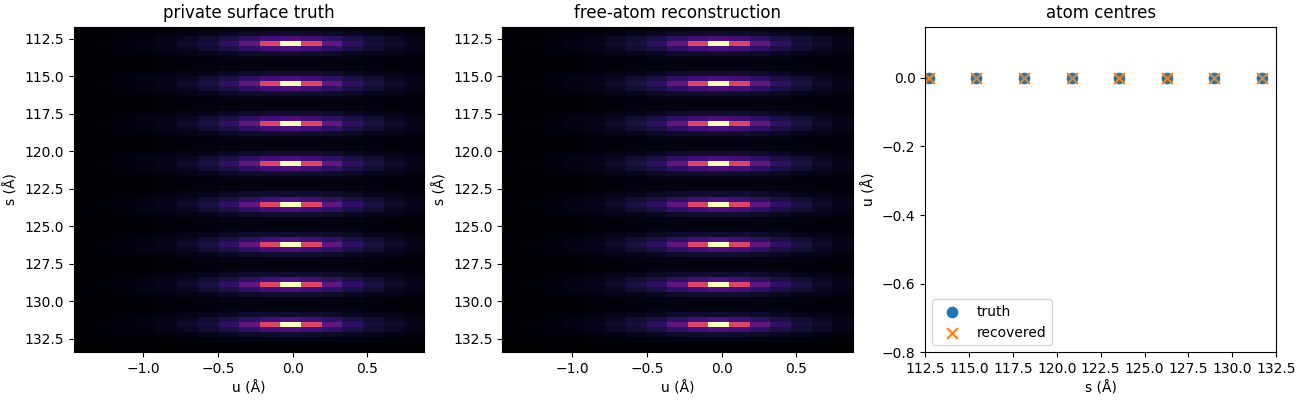

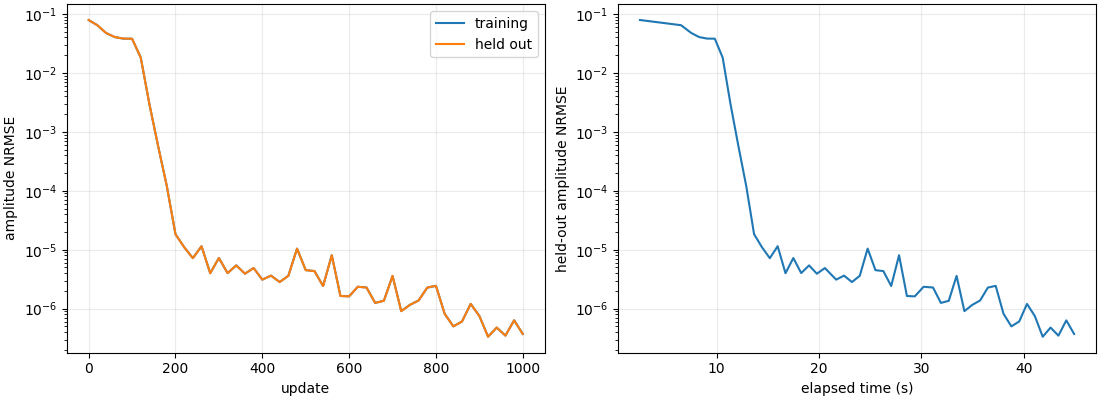

In [8]:
truth_variable = np.asarray(truth_potential - fixed_potential)
recovered_variable = np.asarray(result.potential - fixed_potential)
s_crop = np.where((s_A >= candidate_bounds_A[0, 0] - 1.0) & (s_A <= candidate_bounds_A[0, 1] + 1.0))[0]
u_crop = np.where((u_A >= -1.5) & (u_A <= 1.0))[0]
extent = [u_A[u_crop[0]], u_A[u_crop[-1]], s_A[s_crop[-1]], s_A[s_crop[0]]]
vmax = float(np.max(truth_variable[np.ix_(s_crop, u_crop)]))
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
axes[0].imshow(truth_variable[np.ix_(s_crop, u_crop)], extent=extent, aspect="auto", vmin=0, vmax=vmax, cmap="magma")
axes[1].imshow(recovered_variable[np.ix_(s_crop, u_crop)], extent=extent, aspect="auto", vmin=0, vmax=vmax, cmap="magma")
axes[0].set_title("private surface truth"); axes[1].set_title("free-atom reconstruction")
axes[2].scatter(truth_sites_A[:, 0], truth_sites_A[:, 1], s=55, label="truth")
axes[2].scatter(recovered_sites_A[:, 0], recovered_sites_A[:, 1], marker="x", s=60, label="recovered")
axes[2].set(xlim=candidate_bounds_A[0], ylim=(-0.8, 0.15), xlabel="s (Å)", ylabel="u (Å)", title="atom centres")
axes[2].legend()
for ax in axes[:2]: ax.set(xlabel="u (Å)", ylabel="s (Å)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].semilogy(result.update_history, result.training_loss_history, label="training")
axes[0].semilogy(result.update_history, result.validation_loss_history, label="held out")
axes[0].set(xlabel="update", ylabel="amplitude NRMSE"); axes[0].legend(); axes[0].grid(alpha=0.25)
axes[1].semilogy(result.elapsed_time_history, result.validation_loss_history)
axes[1].set(xlabel="elapsed time (s)", ylabel="held-out amplitude NRMSE"); axes[1].grid(alpha=0.25)

## 7. Traditional pixel ptychography on matched support

The conventional control fits independent non-negative potential pixels, with no atom template, lattice, occupancy, repulsion, or atom count. To avoid favoring the atomic model by clipping its 4 Å template tails, the pixel mask is the same acquisition-derived centre box expanded by the template cutoff. The known exterior is supplied identically to both methods. Checkpoint selection uses the same held-out scans. Thus the principal difference is parameterization: candidate atom positions and occupancies versus thousands of unrelated pixels.


In [9]:
pixel_support_margin_A = 4.0
pixel_mask = (
    (s_A[:, None] >= candidate_bounds_A[0, 0] - pixel_support_margin_A)
    & (s_A[:, None] <= candidate_bounds_A[0, 1] + pixel_support_margin_A)
    & (u_A[None, :] >= candidate_bounds_A[1, 0] - pixel_support_margin_A)
    & (u_A[None, :] <= candidate_bounds_A[1, 1] + pixel_support_margin_A)
)

pixel_result = reconstruct_potential_1d(
    fixed_potential, pixel_mask, input_probes, window_starts, n_s, kernel, ds,
    energy_eV, measured_intensities, fixed_potential=fixed_potential,
    axial_coordinates=jnp.asarray(s_A), transverse_coordinates=jnp.asarray(u_A),
    scan_coordinates=jnp.asarray(scan_coordinates_A),
    validation_indices=validation_indices, potential_scale=50.0,
    potential_max=180.0, updates=1500, minibatch_size=8,
    validation_interval=25, evaluation_batch_size=8,
    learning_rate_start=2e-2, learning_rate_end=2e-4,
    progress=True, progress_description="glancing pixel baseline",
)


glancing pixel baseline:   0%|          | 0/1500 [00:00<?, ?update/s]

## 8. Quantitative comparison

Diffraction agreement is the held-out amplitude NRMSE. Structural and potential errors are simulation-only diagnostics and are not available on experimental data. For atom counting we threshold occupancies at 0.5 only after optimization; the solver itself never receives the true count. Pixel loss histories store squared NRMSE, so their square root is reported below.


{'free Si atoms': {'fitted values': 48,
  'selected atoms': 8,
  'best held-out amplitude NRMSE': 3.344913061161613e-07,
  'variable-potential relative error': 0.00012789245963104603,
  'position RMSE Å': 5.058038728340211e-05},
 'independent pixels': {'fitted values': 4980,
  'selected atoms': 'not defined',
  'best held-out amplitude NRMSE': 0.0027901438299412955,
  'variable-potential relative error': 0.9068334723102704,
  'position RMSE Å': 'not defined'}}

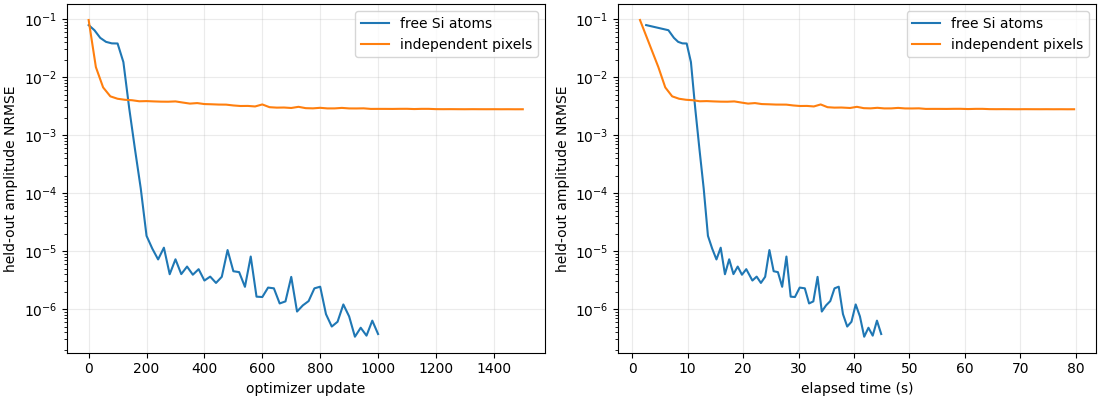

In [10]:
pixel_validation_nrmse = np.sqrt(np.asarray(pixel_result.validation_loss_history))
truth_variable = np.asarray(truth_potential - fixed_potential)
atomic_variable = np.asarray(result.potential - fixed_potential)
pixel_variable = np.asarray(pixel_result.potential - fixed_potential)

def relative_error(estimate, reference):
    return float(np.linalg.norm(estimate - reference) / np.linalg.norm(reference))

comparison = {
    "free Si atoms": {
        "fitted values": int(result.metadata["n_specimen_parameters"]),
        "selected atoms": int(active.sum()),
        "best held-out amplitude NRMSE": float(np.nanmin(result.validation_loss_history)),
        "variable-potential relative error": relative_error(atomic_variable, truth_variable),
        "position RMSE Å": position_rmse_A,
    },
    "independent pixels": {
        "fitted values": int(pixel_mask.sum()),
        "selected atoms": "not defined",
        "best held-out amplitude NRMSE": float(np.nanmin(pixel_validation_nrmse)),
        "variable-potential relative error": relative_error(pixel_variable, truth_variable),
        "position RMSE Å": "not defined",
    },
}
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].semilogy(result.update_history, result.validation_loss_history, label="free Si atoms")
axes[0].semilogy(pixel_result.update_history, pixel_validation_nrmse, label="independent pixels")
axes[0].set(xlabel="optimizer update", ylabel="held-out amplitude NRMSE")
axes[0].grid(alpha=0.25); axes[0].legend()
axes[1].semilogy(result.elapsed_time_history, result.validation_loss_history, label="free Si atoms")
axes[1].semilogy(pixel_result.elapsed_time_history, pixel_validation_nrmse, label="independent pixels")
axes[1].set(xlabel="elapsed time (s)", ylabel="held-out amplitude NRMSE")
axes[1].grid(alpha=0.25); axes[1].legend()


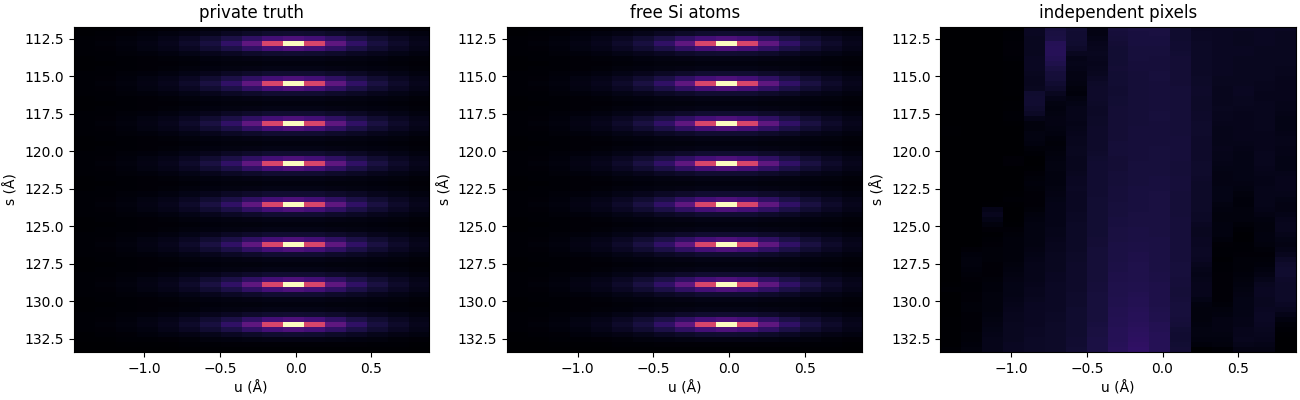

In [11]:
comparison_potentials = {
    "private truth": truth_variable,
    "free Si atoms": atomic_variable,
    "independent pixels": pixel_variable,
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, (name, potential) in zip(axes, comparison_potentials.items()):
    ax.imshow(potential[np.ix_(s_crop, u_crop)], extent=extent, aspect="auto",
              vmin=0, vmax=vmax, cmap="magma")
    ax.set(title=name, xlabel="u (Å)", ylabel="s (Å)")


## 9. Watch the selected row evolve

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
axes[0].imshow(truth_variable[np.ix_(s_crop, u_crop)], extent=extent, aspect="auto", vmin=0, vmax=vmax, cmap="magma")
axes[0].set_title("private truth")
first = render_free_atoms_1d(model, result.position_history[0], result.occupancy_history[0]) - fixed_potential
artist = axes[1].imshow(np.asarray(first)[np.ix_(s_crop, u_crop)], extent=extent, aspect="auto", vmin=0, vmax=vmax, cmap="magma")
title = axes[1].set_title("update 0")
for ax in axes: ax.set(xlabel="u (Å)", ylabel="s (Å)")

def update_animation(frame):
    variable = render_free_atoms_1d(
        model, result.position_history[frame], result.occupancy_history[frame]
    ) - fixed_potential
    artist.set_data(np.asarray(variable)[np.ix_(s_crop, u_crop)])
    title.set_text(f"reconstruction: update {int(result.snapshot_updates[frame])}")
    return artist, title

animation = FuncAnimation(fig, update_animation, frames=len(result.snapshot_updates), interval=120, blit=False)
plt.close(fig)
HTML(animation.to_jshtml())

## 10. Compare propagated truth and reconstruction

In [13]:
reconstructed_sideviews = simulate_glancing_sideview_cache_1d(
    result.potential, input_probes, window_starts, n_s, kernel, ds, energy_eV,
    jnp.arange(len(scan_coordinates_A)), transverse_coordinates=jnp.asarray(u_A),
    scan_coordinates=jnp.asarray(scan_coordinates_A), axial_stride=4, transverse_stride=2,
)
comparison_viewer = make_scan_viewer(
    {"ground truth": truth_sideviews, "reconstruction": reconstructed_sideviews},
    {"ground truth": truth_potential, "reconstruction": result.potential},
)

## Interpretation

This is a successful reconstruction of one acquisition-defined surface row, not of the complete 15 Å slab. The axial interval comes from the scan landing range with a beam-waist edge guard; the transverse interval is the declared top-layer hypothesis. The atom count is not supplied: redundant candidates are removed by their occupancies.

The pixel baseline is the appropriate traditional control because it uses the same forward model, data split, fixed exterior, and a support large enough to contain every atomic tail. Its larger parameter count makes explicit what the known-silicon prior contributes. A low held-out diffraction residual is not by itself proof of the correct structure, so the simulation also reports atom-count, position, and potential errors.

Development trials that freed three layers (23 atoms) and a wider 4.5 Å region (52 atoms) did not recover reliable structures with this 1D detector acquisition, even when their diffraction residuals decreased. The defensible volume-selection rule is therefore: infer axial extent from illumination overlap, declare the shallowest physically justified depth band, and expand depth only when held-out data and structural stability across initializations support it. Full unknown-depth recovery needs more acquisition diversity.
